# Champaign-Urbana Landlords: What 6,700 Google Reviews Reveal

Every August, thousands of University of Illinois Urbana-Champaign (UIUC) students move into off-campus apartments, and many of them choose a landlord the same way: by scrolling through Google reviews. This notebook takes a close look at those reviews for **42 apartment buildings and rental agencies in Champaign and Urbana, IL**.

The companion post [Data Analysis of College Town Landlords at UIUC, BYU, and PSU](../campus-leasing-company-reviews/05-analysis-blog.ipynb) compared Champaign-Urbana with two other college towns. This notebook stays in Champaign-Urbana and digs into the landlords themselves.

**Data:** Business listings (`businesses.csv`, 42 landlords) and their reviews (`reviews-with-names.csv`, 6,736 reviews posted between August 2011 and August 2023) collected from [Google Maps](https://www.google.com/maps). Each review has a 1-5 star rating, the review text, a timestamp, a "likes" count, and the owner's response (if any). Reviewer names and IDs are in the raw file but are never displayed in this notebook.

**Questions**

1. Which landlords rate best and worst once we account for how many reviews each one has?
2. Do some landlords receive bursts of 5★ reviews on a single day, and how much do those bursts move the rankings?
3. How have ratings changed over the years, and is there a season when tenants are least happy?
4. What do unhappy tenants complain about, and does it differ by landlord?
5. Who responds to reviews, which reviews get a reply, and is responding associated with better ratings?

## 🧹 Data Preparation

The cells below load the two tables, parse the timestamps, and drop the `name` column from the reviews table (the business name already lives in `businesses.csv` and can be joined back through `google_place_id`). The trimmed reviews table is saved as `reviews.csv`. The owner-response timestamp is parsed in place, so the saved file has a single `owner_response_datetime_utc` column.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
pd.set_option('display.max_columns', 50)

In [3]:
df_b = pd.read_csv('businesses.csv')
df_b.head(2)

,google_place_id,name,site,category,phone,street,city,zipcode,state,latitude,longitude,working_hours,business_status,about,verified
0,ChIJjy21MDbXDIgRG8W0CUaifWM,Bankier Apartments,http://www.bankierapartments.com/,Apartment rental agency,+1 217-328-3770,406 E Green St,Champaign,61820,Illinois,40.110661,-88.232315,"{""Monday"": ""8 AM-5 PM"", ""Tuesday"": ""8 AM-5 PM""...",OPERATIONAL,"{""Accessibility"": {""Wheelchair accessible entr...",True
1,ChIJX_L4rUnXDIgR9TAeTC_hgXA,University Group,http://ugroupcu.com/,Apartment rental agency,+1 217-352-3182,309 S 1st St,Champaign,61820,Illinois,40.113271,-88.239049,"{""Monday"": ""10 AM-5 PM"", ""Tuesday"": ""10 AM-5 P...",OPERATIONAL,"{""Service options"": {""Online appointments"": tr...",True


In [4]:
df_b['category'].value_counts()

category
Apartment building         18
Apartment rental agency    16
Apartment complex           7
Student housing center      1
Name: count, dtype: int64

In [5]:
df_b.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   google_place_id  42 non-null     str    
 1   name             42 non-null     str    
 2   site             41 non-null     str    
 3   category         42 non-null     str    
 4   phone            42 non-null     str    
 5   street           42 non-null     str    
 6   city             42 non-null     str    
 7   zipcode          42 non-null     int64  
 8   state            42 non-null     str    
 9   latitude         42 non-null     float64
 10  longitude        42 non-null     float64
 11  working_hours    40 non-null     str    
 12  business_status  42 non-null     str    
 13  about            42 non-null     str    
 14  verified         42 non-null     bool   
dtypes: bool(1), float64(2), int64(1), str(11)
memory usage: 23.2 KB


Load the reviews. Reviewer names/IDs and owner responses (which often greet the reviewer by first name) are left out of the previews.

In [6]:
df_r = pd.read_csv('reviews-with-names.csv')
df_r.drop(columns=['author_name', 'author_id', 'owner_response_text']).head(2)

,name,google_place_id,review_id,review_text,review_img_url,review_rating,review_datetime_utc,review_likes,owner_response_datetime_utc
0,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSURxdWF1eERREAE,I lived here for about 2 years. Did not have a...,NaN,5,2021-07-13 19:57:53,0,NaN
1,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSUNlaTdHS0tREAE,I leased one of their single bedroom apartment...,NaN,5,2022-09-23 17:29:10,0,NaN


In [7]:
df_r['review_datetime_utc'] = pd.to_datetime(df_r['review_datetime_utc'])
df_r['owner_response_datetime_utc'] = pd.to_datetime(df_r['owner_response_datetime_utc'])

In [8]:
df_r.info()

<class 'pandas.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   name                         6736 non-null   str           
 1   google_place_id              6736 non-null   str           
 2   review_id                    6736 non-null   str           
 3   author_name                  6736 non-null   str           
 4   author_id                    6736 non-null   object        
 5   review_text                  6736 non-null   str           
 6   review_img_url               123 non-null    str           
 7   review_rating                6736 non-null   int64         
 8   review_datetime_utc          6736 non-null   datetime64[us]
 9   review_likes                 6736 non-null   int64         
 10  owner_response_text          4161 non-null   str           
 11  owner_response_datetime_utc  4161 non-null   datetime6

In [9]:
df_r.drop(columns=['author_name', 'author_id', 'owner_response_text']).head()

,name,google_place_id,review_id,review_text,review_img_url,review_rating,review_datetime_utc,review_likes,owner_response_datetime_utc
0,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSURxdWF1eERREAE,I lived here for about 2 years. Did not have a...,NaN,5,2021-07-13 19:57:53,0,NaT
1,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSUNlaTdHS0tREAE,I leased one of their single bedroom apartment...,NaN,5,2022-09-23 17:29:10,0,NaT
2,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChdDSUhNMG9nS0VJQ0FnSURpdnFXY2h3RRAB,I am in my third year of living with Bankier a...,NaN,5,2020-12-03 22:47:12,0,2020-12-07 22:08:12
3,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChdDSUhNMG9nS0VJQ0FnSUNoaUlpTV9nRRAB,I cannot open my door on this morning.And I ha...,NaN,5,2023-02-03 15:57:31,0,2023-05-08 17:15:31
4,Bankier Apartments,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSUNlN2FXaE9nEAE,Their office is on the heart of Green Street o...,NaN,2,2022-09-21 05:33:09,0,NaT


In [10]:
df_r.drop(columns=['name'], inplace=True)

In [11]:
df_r.info()

<class 'pandas.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   google_place_id              6736 non-null   str           
 1   review_id                    6736 non-null   str           
 2   author_name                  6736 non-null   str           
 3   author_id                    6736 non-null   object        
 4   review_text                  6736 non-null   str           
 5   review_img_url               123 non-null    str           
 6   review_rating                6736 non-null   int64         
 7   review_datetime_utc          6736 non-null   datetime64[us]
 8   review_likes                 6736 non-null   int64         
 9   owner_response_text          4161 non-null   str           
 10  owner_response_datetime_utc  4161 non-null   datetime64[us]
dtypes: datetime64[us](2), int64(2), object(1), str(6)
memo

In [12]:
df_r.drop(columns=['author_name', 'author_id', 'owner_response_text']).head()

,google_place_id,review_id,review_text,review_img_url,review_rating,review_datetime_utc,review_likes,owner_response_datetime_utc
0,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSURxdWF1eERREAE,I lived here for about 2 years. Did not have a...,NaN,5,2021-07-13 19:57:53,0,NaT
1,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSUNlaTdHS0tREAE,I leased one of their single bedroom apartment...,NaN,5,2022-09-23 17:29:10,0,NaT
2,ChIJjy21MDbXDIgRG8W0CUaifWM,ChdDSUhNMG9nS0VJQ0FnSURpdnFXY2h3RRAB,I am in my third year of living with Bankier a...,NaN,5,2020-12-03 22:47:12,0,2020-12-07 22:08:12
3,ChIJjy21MDbXDIgRG8W0CUaifWM,ChdDSUhNMG9nS0VJQ0FnSUNoaUlpTV9nRRAB,I cannot open my door on this morning.And I ha...,NaN,5,2023-02-03 15:57:31,0,2023-05-08 17:15:31
4,ChIJjy21MDbXDIgRG8W0CUaifWM,ChZDSUhNMG9nS0VJQ0FnSUNlN2FXaE9nEAE,Their office is on the heart of Green Street o...,NaN,2,2022-09-21 05:33:09,0,NaT


In [13]:
df_r.to_csv('reviews.csv', index=None)

## 🔎 Analysis

### Setup

Join the landlord names and categories back onto the reviews and add a few helper columns. Timestamps are converted from UTC to Champaign-Urbana local time (US Central) so that a "day" or "month" matches the tenants' calendar. Google's `category` is collapsed into two landlord types:

- **Rental agency**: 16 local property managers that run many buildings (e.g., University Group, JSM Living, Green Street Realty).
- **Building / complex**: 26 single properties (apartment buildings, complexes, and one student housing center), a mix of purpose-built student housing near campus and conventional apartment complexes.

In [14]:
import re
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.feature_extraction.text import CountVectorizer

pio.templates['sans_serif'] = go.layout.Template(dict(layout=go.Layout(
    font_family='Helvetica, Inter, Arial, sans-serif')))
pio.templates.default = 'simple_white+sans_serif'

# rating colors used in the cross-campus blog post
rating_colors = {'1': '#EF5350', '2': '#EF9A9A', '3': '#FDD835', '4': '#9CCC65', '5': '#689F38'}
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [15]:
df = df_r.merge(
    df_b[['google_place_id', 'name', 'category', 'verified']],
    on='google_place_id',
    how='left'
)

# UTC -> Champaign-Urbana local time, so "day" and "month" follow the tenants' calendar
df['review_datetime_local'] = df['review_datetime_utc'] \
    .dt.tz_localize('UTC') \
    .dt.tz_convert('America/Chicago') \
    .dt.tz_localize(None)
df['review_day'] = df['review_datetime_local'].dt.normalize()
df['year'] = df['review_datetime_local'].dt.year
df['month'] = df['review_datetime_local'].dt.month

df['landlord_type'] = np.where(
    df['category'] == 'Apartment rental agency', 'Rental agency', 'Building / complex'
)
df['review_length'] = df['review_text'].str.len()
df['responded'] = df['owner_response_text'].notna()
df['response_days'] = (df['owner_response_datetime_utc'] - df['review_datetime_utc']) / pd.Timedelta(days=1)

print(f"{df.shape[0]:,} reviews of {df['name'].nunique()} landlords, "
      f"posted {df['review_datetime_local'].min():%Y-%m-%d} to {df['review_datetime_local'].max():%Y-%m-%d}")
df[['name', 'landlord_type', 'review_rating', 'review_datetime_local', 'review_length', 'responded']].head(3)

6,736 reviews of 42 landlords, posted 2011-08-12 to 2023-08-28


,name,landlord_type,review_rating,review_datetime_local,review_length,responded
0,Bankier Apartments,Rental agency,5,2021-07-13 14:57:53,130,False
1,Bankier Apartments,Rental agency,5,2022-09-23 12:29:10,745,False
2,Bankier Apartments,Rental agency,5,2020-12-03 16:47:12,453,True


In [16]:
df['landlord_type'].value_counts()

landlord_type
Building / complex    3395
Rental agency         3341
Name: count, dtype: int64

### 👉 1. Ratings are polarized: tenants either love or hate their landlord

In [17]:
df_rating_counts = df['review_rating'].value_counts().sort_index().to_frame().reset_index()
df_rating_counts['percentage'] = df_rating_counts['count'] / df_rating_counts['count'].sum()
df_rating_counts['stars'] = df_rating_counts['review_rating'].astype(str)
df_rating_counts

,review_rating,count,percentage,stars
0,1,1616,0.239905,1
1,2,211,0.031324,2
2,3,152,0.022565,3
3,4,505,0.074970,4
4,5,4252,0.631235,5


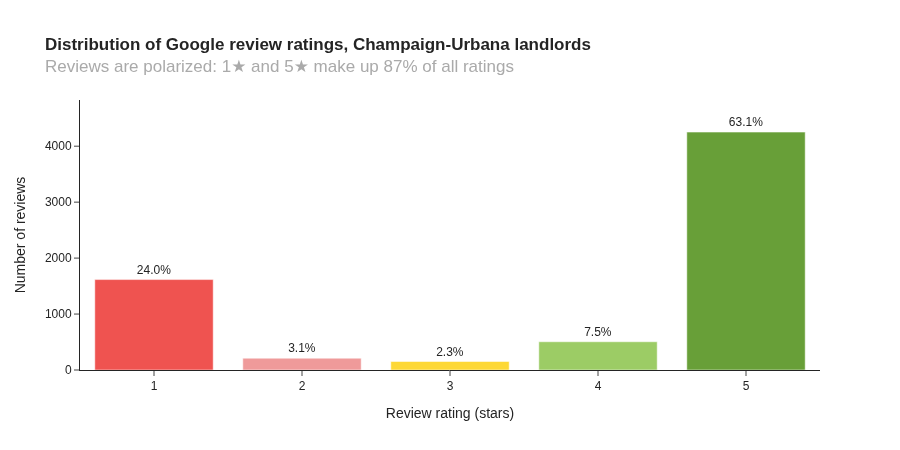

In [18]:
fig = px.bar(
    df_rating_counts,
    x='stars',
    y='count',
    color='stars',
    color_discrete_map=rating_colors,
    text=df_rating_counts['percentage'].map('{:.1%}'.format),
    labels={'stars': 'Review rating (stars)', 'count': 'Number of reviews'},
    title='<b>Distribution of Google review ratings, Champaign-Urbana landlords</b><br>'
          '<span style="color: #aaa;">Reviews are polarized: 1★ and 5★ make up 87% of all ratings</span>',
    width=900, height=450
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

In [19]:
df_landlords = df.groupby(['name', 'landlord_type', 'verified'], as_index=False).agg(
    num_reviews=('review_id', 'count'),
    avg_rating=('review_rating', 'mean'),
    one_star_share=('review_rating', lambda s: (s == 1).mean()),
    five_star_share=('review_rating', lambda s: (s == 5).mean()),
)

r = df_landlords['avg_rating'].corr(df_landlords['one_star_share'])
print(f'Correlation between a landlord\'s average rating and its share of 1★ reviews: {r:.2f}')
print(f"Reviews per landlord: median {df_landlords['num_reviews'].median():.0f}, "
      f"min {df_landlords['num_reviews'].min()}, max {df_landlords['num_reviews'].max()}")

Correlation between a landlord's average rating and its share of 1★ reviews: -0.95
Reviews per landlord: median 120, min 16, max 529


- 63.1% of reviews are 5★ and 24.0% are 1★. The middle ratings (2-4★) together make up only 12.9%.
- Because ratings are so polarized, a landlord's average rating is almost entirely determined by its share of 1★ reviews (correlation of -0.95 across the 42 landlords). An average of "3.8 stars" really means "roughly one in four reviewers had a terrible experience."
- Review counts vary a lot, from 16 to 529 per landlord (median 120), so the averages of small landlords are noisy.

### 👉 2. Landlord leaderboard with shrunk (Bayesian) averages

A landlord with 16 reviews averaging 4.5★ should not automatically outrank one with 400 reviews averaging 4.2★. A simple fix is a **Bayesian (shrunk) average**: pretend every landlord also has `m = 50` extra reviews at the overall average rating, then recompute.

$$\text{shrunk average} = \frac{n \cdot \bar{x} + m \cdot \mu}{n + m}$$

where $n$ is the landlord's number of reviews, $\bar{x}$ its average rating, and $\mu$ the overall average rating across all reviews. Landlords with few reviews are pulled toward $\mu$, while landlords with hundreds of reviews barely move.

In [20]:
prior_weight = 50  # the prior counts as 50 "average" reviews
global_mean = df['review_rating'].mean()

df_landlords['shrunk_avg'] = (
    (df_landlords['avg_rating'] * df_landlords['num_reviews'] + prior_weight * global_mean)
    / (df_landlords['num_reviews'] + prior_weight)
)
df_landlords['raw_rank'] = df_landlords['avg_rating'].rank(ascending=False, method='min').astype(int)
df_landlords['rank'] = df_landlords['shrunk_avg'].rank(ascending=False, method='min').astype(int)
df_landlords = df_landlords.sort_values('rank').reset_index(drop=True)

print(f'Overall average rating (prior mean): {global_mean:.2f}')
mover = df_landlords.loc[(df_landlords['raw_rank'] - df_landlords['rank']).abs().idxmax()]
print(f"Biggest shrinkage move: {mover['name']} (n={mover['num_reviews']}): raw average {mover['avg_rating']:.2f} "
      f"(rank {mover['raw_rank']}) -> shrunk {mover['shrunk_avg']:.2f} (rank {mover['rank']})")
leaderboard_cols = ['rank', 'raw_rank', 'name', 'num_reviews', 'avg_rating', 'shrunk_avg', 'one_star_share']
pd.concat([df_landlords[leaderboard_cols].head(5), df_landlords[leaderboard_cols].tail(5)]).round(2)

Overall average rating (prior mean): 3.83
Biggest shrinkage move: ICON Apartment (n=16): raw average 4.50 (rank 3) -> shrunk 3.99 (rank 11)


,rank,raw_rank,name,num_reviews,avg_rating,shrunk_avg,one_star_share
0,1,1,Hub on Campus Champaign - Daniel,318,4.81,4.67,0.01
1,2,2,Stone Ridge Square Apartments,62,4.58,4.24,0.03
2,3,6,212 East,203,4.32,4.22,0.12
3,4,8,Community Property Management,407,4.24,4.20,0.15
4,5,9,Fairlawn Real Estate Property Management,362,4.23,4.18,0.17
37,38,37,Latitude Apartments,262,3.42,3.48,0.34
38,39,40,The Pointe At U of I,148,3.08,3.27,0.37
39,40,39,Green Street Realty,508,3.21,3.27,0.41
40,41,41,Town & Country Apartments,113,3.00,3.25,0.44
41,42,42,Ramshaw Real Estate,162,2.99,3.19,0.40


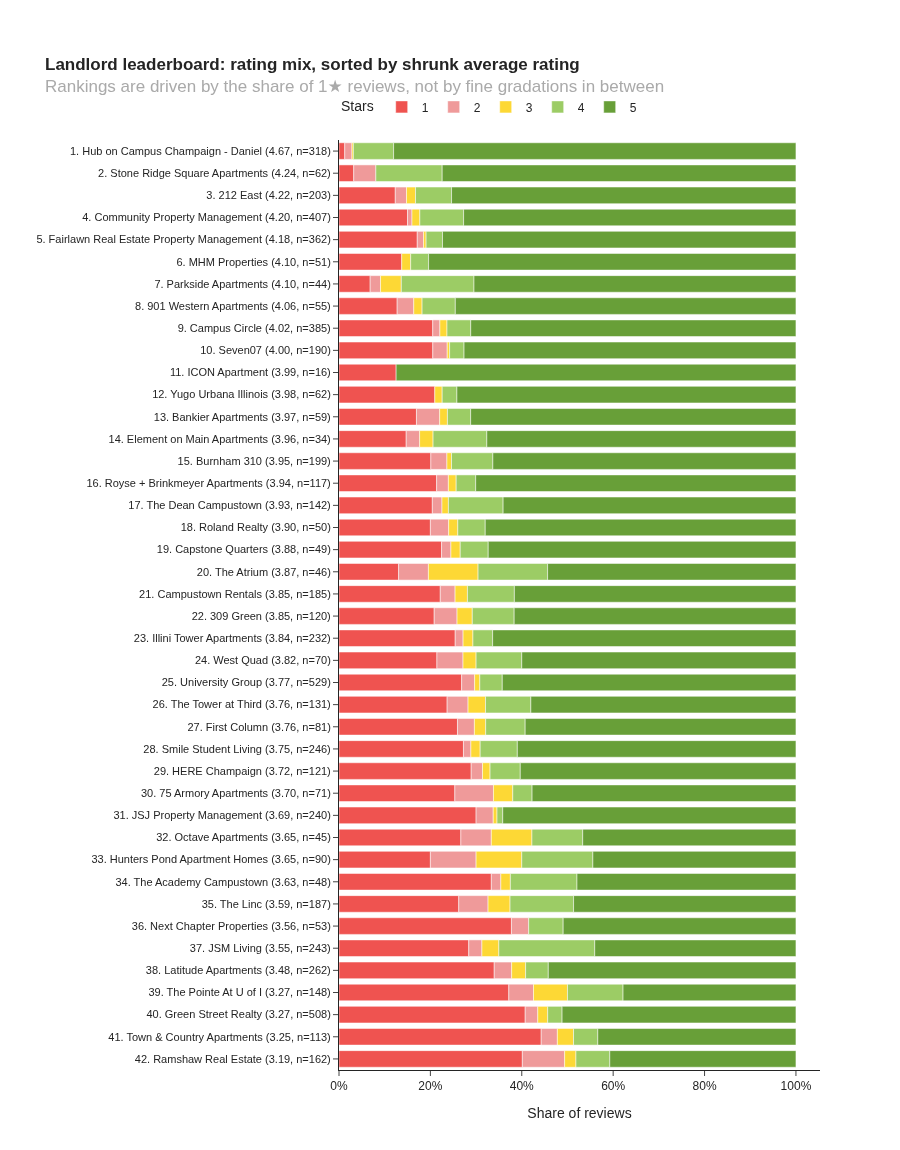

In [21]:
df_mix = df.assign(stars=df['review_rating'].astype(str)) \
    .groupby(['name', 'stars'], as_index=False) \
    .agg({'review_id': 'count'}) \
    .rename(columns={'review_id': 'num_reviews'})
df_mix['percentage'] = df_mix['num_reviews'] / df_mix.groupby('name')['num_reviews'].transform('sum')

# label each landlord with its leaderboard rank, shrunk average, and review count
labels = df_landlords.set_index('name').apply(
    lambda r: f"{r['rank']}. {r.name} ({r['shrunk_avg']:.2f}, n={r['num_reviews']})", axis=1
)
df_mix['landlord'] = df_mix['name'].map(labels)

fig = px.bar(
    df_mix,
    x='percentage',
    y='landlord',
    color='stars',
    color_discrete_map=rating_colors,
    category_orders={'landlord': labels.loc[df_landlords['name']].tolist(), 'stars': ['1', '2', '3', '4', '5']},
    orientation='h',
    labels={'percentage': 'Share of reviews', 'landlord': '', 'stars': 'Stars'},
    title='<b>Landlord leaderboard: rating mix, sorted by shrunk average rating</b><br>'
          '<span style="color: #aaa;">Rankings are driven by the share of 1★ reviews, not by fine gradations in between</span>',
    width=900, height=1150
)
fig.update_layout(xaxis_tickformat=',.0%', legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'),
                  margin=dict(t=140), bargap=0.25)
fig.update_yaxes(tickfont_size=11)
fig.show()

- **Top 5:** Hub on Campus Champaign - Daniel (4.67), Stone Ridge Square Apartments (4.24), 212 East (4.22), Community Property Management (4.20), and Fairlawn Real Estate Property Management (4.18).
- **Bottom 5:** Ramshaw Real Estate (3.19), Town & Country Apartments (3.25), Green Street Realty (3.27), The Pointe At U of I (3.27), and Latitude Apartments (3.48). Green Street Realty, the second most-reviewed landlord (508 reviews), has 41% 1★ reviews.
- Shrinkage matters mostly for small landlords: ICON Apartment (n=16) drops from a raw 4.50 (rank 3) to 3.99 (rank 11).
- The chart shows the polarization at the landlord level: moving down the leaderboard, the red 1★ segment grows while the 2-4★ segments stay thin.

But there is a catch. The #1 landlord, Hub on Campus, has 318 reviews, and the next section shows that most of them arrived on a handful of days.

### 👉 3. Review spike days: dozens of 5★ reviews in a single afternoon

Most landlords receive a new review every few days at most. So what is going on when a landlord gets 20, 50, or 76 reviews on the same day?

Define a **spike day** as a landlord-day (local time) with **5 or more reviews**. The cutoff is a judgment call, so a robustness check with 3 and 10 reviews per day follows.

In [22]:
df['reviews_same_day'] = df.groupby(['google_place_id', 'review_day'])['review_id'].transform('count')
df['spike_day'] = df['reviews_same_day'] >= 5

df_days = df.groupby(['name', 'review_day'], as_index=False).agg(
    num_reviews=('review_id', 'count'),
    five_star_share=('review_rating', lambda s: (s == 5).mean()),
    first_review=('review_datetime_local', 'min'),
    last_review=('review_datetime_local', 'max'),
)
df_days['reviews_that_day'] = pd.cut(
    df_days['num_reviews'], bins=[0, 1, 4, 9, 19, 1000], labels=['1', '2-4', '5-9', '10-19', '20+']
)
df_days.groupby('reviews_that_day', observed=True, as_index=False).agg(
    landlord_days=('num_reviews', 'count'),
    reviews=('num_reviews', 'sum'),
)

,reviews_that_day,landlord_days,reviews
0,1,3625,3625
1,2-4,684,1645
2,5-9,110,683
3,10-19,35,474
4,20+,7,309


In [23]:
df_spike_summary = df.groupby('spike_day', as_index=False).agg(
    num_reviews=('review_id', 'count'),
    avg_rating=('review_rating', 'mean'),
    five_star_share=('review_rating', lambda s: (s == 5).mean()),
    one_star_share=('review_rating', lambda s: (s == 1).mean()),
    median_length=('review_length', 'median'),
)
df_spike_summary['share_of_reviews'] = df_spike_summary['num_reviews'] / df_spike_summary['num_reviews'].sum()
print(f"Spike days: {(df_days['num_reviews'] >= 5).sum()} landlord-days across "
      f"{df_days.query('num_reviews >= 5')['name'].nunique()} landlords")
df_spike_summary.round({'avg_rating': 2, 'five_star_share': 3, 'one_star_share': 3, 'share_of_reviews': 3})

Spike days: 152 landlord-days across 33 landlords


,spike_day,num_reviews,avg_rating,five_star_share,one_star_share,median_length,share_of_reviews
0,False,5270,3.57,0.565,0.298,205.0,0.782
1,True,1466,4.76,0.868,0.030,124.0,0.218


In [24]:
# robustness: how sensitive is the comparison to the 5-reviews-per-day cutoff?
pd.DataFrame([
    {
        'cutoff': f'{k}+ reviews/day',
        'share_flagged': (df['reviews_same_day'] >= k).mean(),
        'avg_rating_flagged': df.loc[df['reviews_same_day'] >= k, 'review_rating'].mean(),
        'avg_rating_other': df.loc[df['reviews_same_day'] < k, 'review_rating'].mean(),
    }
    for k in [3, 5, 10]
]).round(2)

,cutoff,share_flagged,avg_rating_flagged,avg_rating_other
0,3+ reviews/day,0.32,4.62,3.45
1,5+ reviews/day,0.22,4.76,3.57
2,10+ reviews/day,0.12,4.88,3.69


In [25]:
df_top_days = df_days.sort_values('num_reviews', ascending=False).head(10).copy()
df_top_days['hours_span'] = (df_top_days['last_review'] - df_top_days['first_review']) / pd.Timedelta(hours=1)
df_top_days['review_day'] = df_top_days['review_day'].dt.date
df_top_days[['name', 'review_day', 'num_reviews', 'five_star_share', 'hours_span']].round(2)

,name,review_day,num_reviews,five_star_share,hours_span
2039,Illini Tower Apartments,2022-10-27,76,0.99,7.71
1864,Hub on Campus Champaign - Daniel,2023-05-02,53,0.91,7.96
681,Campustown Rentals,2021-03-05,53,0.91,2.84
1865,Hub on Campus Champaign - Daniel,2023-05-03,51,0.80,12.56
58,212 East,2023-03-24,27,0.81,9.13
347,Burnham 310,2021-10-18,26,0.77,5.70
57,212 East,2023-03-23,23,0.83,8.62
1840,Hub on Campus Champaign - Daniel,2021-05-21,19,1.00,3.04
2548,Latitude Apartments,2021-11-09,19,1.00,9.33
1460,Green Street Realty,2018-06-26,19,0.95,11.64


In [26]:
# three properties whose Google listings link to the same national operator's website
acc_ids = df_b.loc[df_b['site'].str.contains('americancampus.com', na=False), 'google_place_id']
df.loc[df['google_place_id'].isin(acc_ids)] \
    .groupby(['name', 'review_day'], as_index=False) \
    .agg(num_reviews=('review_id', 'count'), avg_rating=('review_rating', 'mean')) \
    .sort_values('num_reviews', ascending=False) \
    .head(3)

,name,review_day,num_reviews,avg_rating
103,Campustown Rentals,2021-03-05,53,4.90566
194,The Tower at Third,2021-03-05,16,4.87500
48,309 Green,2021-03-05,16,4.50000


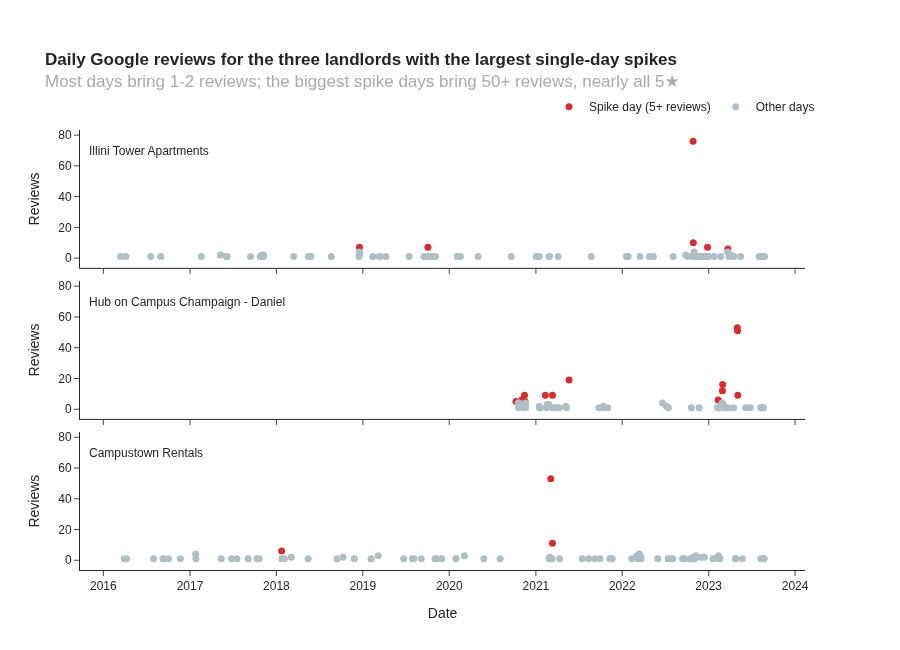

In [27]:
top_spike_landlords = df_days.sort_values('num_reviews', ascending=False)['name'].unique()[:3]

df_timeline = df_days[df_days['name'].isin(top_spike_landlords) & (df_days['review_day'] >= '2016-01-01')].copy()
df_timeline['day_type'] = np.where(df_timeline['num_reviews'] >= 5, 'Spike day (5+ reviews)', 'Other days')

fig = px.scatter(
    df_timeline,
    x='review_day',
    y='num_reviews',
    color='day_type',
    color_discrete_map={'Spike day (5+ reviews)': '#D32F2F', 'Other days': '#B0BEC5'},
    facet_row='name',
    category_orders={'name': list(top_spike_landlords), 'day_type': ['Spike day (5+ reviews)', 'Other days']},
    hover_data={'five_star_share': ':.0%'},
    labels={'review_day': 'Date', 'num_reviews': 'Reviews', 'day_type': '', 'name': '',
            'five_star_share': '5★ share'},
    title='<b>Daily Google reviews for the three landlords with the largest single-day spikes</b><br>'
          '<span style="color: #aaa;">Most days bring 1-2 reviews; the biggest spike days bring 50+ reviews, nearly all 5★</span>',
    width=900, height=650
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1], textangle=0, x=0.01, xanchor='left',
                                           y=a.y + 0.11, font_size=12))
fig.update_traces(marker_size=7)
fig.update_layout(legend=dict(orientation='h', y=1.02, x=1, xanchor='right', yanchor='bottom'),
                  margin=dict(t=130))
fig.show()

In [28]:
# landlords with the highest share of reviews posted on spike days
df.groupby('name', as_index=False).agg(
    num_reviews=('review_id', 'count'),
    spike_days=('review_day', lambda s: s[df.loc[s.index, 'spike_day']].nunique()),
    spike_share=('spike_day', 'mean'),
).sort_values('spike_share', ascending=False).head(8).round(2)

,name,num_reviews,spike_days,spike_share
15,Hub on Campus Champaign - Daniel,318,18,0.74
0,212 East,203,9,0.57
18,Illini Tower Apartments,232,6,0.49
1,309 Green,120,6,0.42
41,Yugo Urbana Illinois,62,2,0.42
5,Burnham 310,199,8,0.41
7,Campustown Rentals,185,3,0.38
37,The Tower at Third,131,5,0.37


- On most landlord-days with any reviews (3,625), exactly one review was posted. Only **152 spike days across 33 landlords** had 5 or more, yet they account for **1,466 reviews (21.8% of all reviews)**.
- Spike-day reviews look very different: they average 4.76★ (86.8% 5★, 3.0% 1★) compared with 3.57★ (56.5% 5★, 29.8% 1★) on other days, and they are shorter (median 124 vs 205 characters). The gap holds at any cutoff: 4.62★ vs 3.45★ at 3+ reviews per day, and 4.88★ vs 3.69★ at 10+.
- **Illini Tower Apartments received 76 reviews on October 27, 2022** (99% 5★, all within about 7.7 hours). **Hub on Campus received 53 and 51 reviews on May 2 and 3, 2023.** Campustown Rentals received 53 reviews within 2.8 hours on March 5, 2021, the same day that The Tower at Third and 309 Green received 16 reviews each. All three of those listings link to the same national operator's website (americancampus.com).
- For some landlords, spike days produce most of their reviews: 74% of Hub on Campus's reviews (from 18 spike days) and 57% of 212 East's, with 49% for Illini Tower Apartments.

**How to read this.** Same-day bursts of short, overwhelmingly positive reviews are consistent with organized review drives, such as a resident event or a leasing-office campaign that asks current tenants to leave a review. These reviewers are very likely real residents, but they are a *prompted* sample, which is different from tenants who decide to write a review on their own. The data cannot tell whether reviews were simply requested, or requested with incentives or only from happy residents (practices that Google's review policies prohibit). Nothing here should be read as an accusation against any landlord.

### 👉 4. How much do spike days move the leaderboard?

Recompute the shrunk averages using only reviews posted on non-spike days ("spike-free" ratings, using the spike-free overall average as the prior mean). Neither version is the "true" rating: spike-day reviewers were prompted, while spontaneous reviewers skew toward people with something to complain about. Comparing the two shows how sensitive the rankings are to review drives.

In [29]:
df_organic = df.query('not spike_day')
organic_mean = df_organic['review_rating'].mean()

df_landlords = df_landlords.merge(
    df.groupby('name', as_index=False).agg(spike_share=('spike_day', 'mean')),
    on='name'
).merge(
    df_organic.groupby('name', as_index=False).agg(
        organic_reviews=('review_id', 'count'),
        organic_avg=('review_rating', 'mean'),
    ),
    on='name'
)
df_landlords['organic_shrunk_avg'] = (
    (df_landlords['organic_avg'] * df_landlords['organic_reviews'] + prior_weight * organic_mean)
    / (df_landlords['organic_reviews'] + prior_weight)
)
df_landlords['organic_rank'] = df_landlords['organic_shrunk_avg'].rank(ascending=False, method='min').astype(int)
df_landlords['rank_change'] = df_landlords['rank'] - df_landlords['organic_rank']

print(f'Average rating, all reviews: {global_mean:.2f} | excluding spike days: {organic_mean:.2f}')
print(f"Rank correlation between the two leaderboards: "
      f"{stats.spearmanr(df_landlords['rank'], df_landlords['organic_rank']).statistic:.2f}")
mover_cols = ['name', 'spike_share', 'shrunk_avg', 'rank', 'organic_shrunk_avg', 'organic_rank', 'rank_change']
pd.concat([
    df_landlords.sort_values('rank_change').head(6),
    df_landlords.sort_values('rank_change').tail(4),
])[mover_cols].round(2)

Average rating, all reviews: 3.83 | excluding spike days: 3.57
Rank correlation between the two leaderboards: 0.82


,name,spike_share,shrunk_avg,rank,organic_shrunk_avg,organic_rank,rank_change
2,212 East,0.57,4.22,3,3.66,18,-15
22,Illini Tower Apartments,0.49,3.84,23,3.23,38,-15
14,Burnham 310,0.41,3.95,15,3.43,29,-14
11,Yugo Urbana Illinois,0.42,3.98,12,3.52,25,-13
20,Campustown Rentals,0.38,3.85,21,3.34,34,-13
25,The Tower at Third,0.37,3.76,26,3.26,36,-10
30,JSJ Property Management,0.05,3.69,31,3.59,21,10
32,Hunters Pond Apartment Homes,0.00,3.65,33,3.55,23,10
24,University Group,0.02,3.77,25,3.78,12,13
27,Smile Student Living,0.04,3.75,28,3.75,15,13


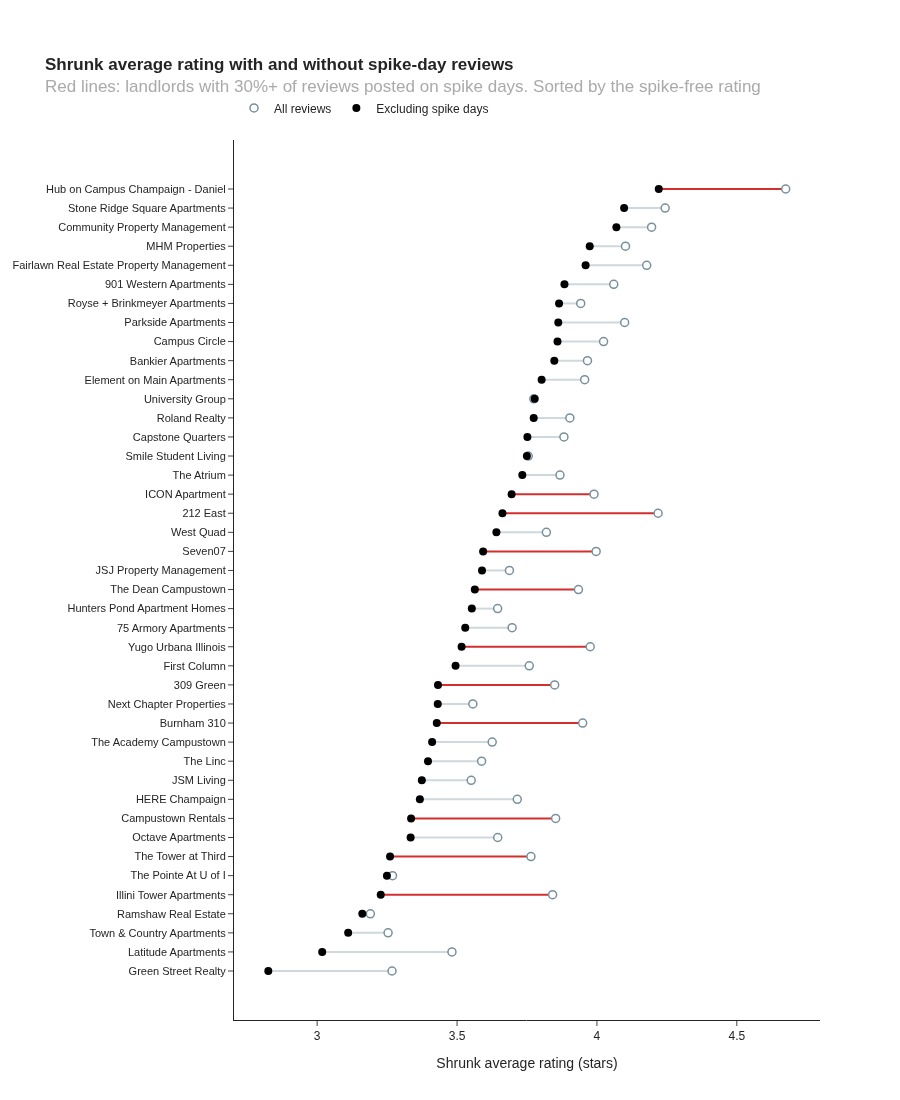

In [30]:
df_dumbbell = df_landlords.sort_values('organic_shrunk_avg')
high_spike = df_dumbbell['spike_share'] >= 0.3

fig = go.Figure()
for _, row in df_dumbbell.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['organic_shrunk_avg'], row['shrunk_avg']],
        y=[row['name'], row['name']],
        mode='lines',
        line=dict(color='#D32F2F' if row['spike_share'] >= 0.3 else '#CFD8DC', width=2),
        showlegend=False,
        hoverinfo='skip',
    ))
fig.add_trace(go.Scatter(
    x=df_dumbbell['shrunk_avg'], y=df_dumbbell['name'], mode='markers', name='All reviews',
    marker=dict(color='white', size=8, line=dict(color='#78909C', width=1.5)),
    customdata=df_dumbbell[['spike_share']], hovertemplate='%{y}<br>All reviews: %{x:.2f}<br>'
                                                           'Spike-day share: %{customdata[0]:.0%}<extra></extra>'
))
fig.add_trace(go.Scatter(
    x=df_dumbbell['organic_shrunk_avg'], y=df_dumbbell['name'], mode='markers', name='Excluding spike days',
    marker=dict(color='black', size=8),
    hovertemplate='%{y}<br>Excluding spike days: %{x:.2f}<extra></extra>'
))
fig.update_layout(
    title='<b>Shrunk average rating with and without spike-day reviews</b><br>'
          '<span style="color: #aaa;">Red lines: landlords with 30%+ of reviews posted on spike days. '
          'Sorted by the spike-free rating</span>',
    xaxis_title='Shrunk average rating (stars)',
    width=900, height=1100,
    legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'),
    margin=dict(t=140),
)
fig.update_yaxes(tickfont_size=11)
fig.show()

In [31]:
df_type = df.groupby('landlord_type', as_index=False).agg(
    num_landlords=('name', 'nunique'),
    num_reviews=('review_id', 'count'),
    spike_share=('spike_day', 'mean'),
    avg_rating=('review_rating', 'mean'),
    response_rate=('responded', 'mean'),
).merge(
    df_organic.groupby('landlord_type', as_index=False).agg(organic_avg=('review_rating', 'mean')),
    on='landlord_type'
)
df_type.round(2)

,landlord_type,num_landlords,num_reviews,spike_share,avg_rating,response_rate,organic_avg
0,Building / complex,26,3395,0.31,3.91,0.80,3.52
1,Rental agency,16,3341,0.12,3.74,0.43,3.60


- Excluding spike-day reviews lowers the overall average from 3.83 to 3.57. The two leaderboards are still related (rank correlation of 0.82), but individual landlords move a lot.
- **Biggest fallers:** 212 East (#3 → #18; 57% of its reviews were posted on spike days), Illini Tower Apartments (#23 → #38), Burnham 310 (#15 → #29), Yugo Urbana Illinois (#12 → #25), Campustown Rentals (#21 → #34), and The Tower at Third (#26 → #36).
- **Biggest risers** are landlords with few or no spike days: University Group (#25 → #12), Smile Student Living (#28 → #15), JSJ Property Management (#31 → #21), and Hunters Pond Apartment Homes (#33 → #23).
- Hub on Campus still tops the spike-free leaderboard, and Green Street Realty moves to the bottom.
- **The building-vs-agency comparison flips.** Single buildings/complexes post 31% of their reviews on spike days, compared with 12% for rental agencies. With all reviews, buildings look better (3.91 vs 3.74). Without spike days, rental agencies come out slightly ahead (3.60 vs 3.52).

### 👉 5. Trends over time: review drives mask a dip

Yearly volume and ratings from 2015 onward (earlier years have fewer than 70 reviews each). The data ends on August 28, 2023 (local time), so 2023 covers January through August only.

In [32]:
df_yearly = df.query('year >= 2015').groupby('year', as_index=False).agg(
    num_reviews=('review_id', 'count'),
    spike_share=('spike_day', 'mean'),
    avg_rating=('review_rating', 'mean'),
    response_rate=('responded', 'mean'),
).merge(
    df_organic.query('year >= 2015').groupby('year', as_index=False).agg(
        organic_avg=('review_rating', 'mean'),
        organic_one_star_share=('review_rating', lambda s: (s == 1).mean()),
    ),
    on='year'
)
df_yearly.round(2)

,year,num_reviews,spike_share,avg_rating,response_rate,organic_avg,organic_one_star_share
0,2015,137,0.00,3.52,0.17,3.52,0.27
1,2016,274,0.12,3.45,0.37,3.28,0.34
2,2017,490,0.06,3.43,0.42,3.43,0.32
3,2018,867,0.18,3.99,0.39,3.86,0.23
4,2019,776,0.12,3.90,0.57,3.78,0.26
5,2020,951,0.27,4.08,0.70,3.76,0.26
6,2021,930,0.34,3.84,0.71,3.30,0.37
7,2022,1118,0.22,3.64,0.73,3.35,0.36
8,2023,1089,0.30,4.00,0.82,3.66,0.28


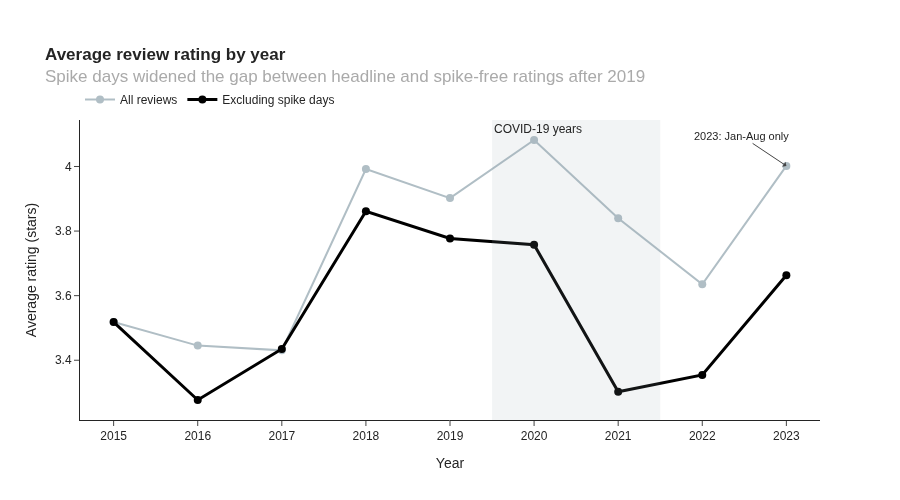

In [33]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_yearly['year'], y=df_yearly['avg_rating'], name='All reviews',
    mode='lines+markers', line=dict(color='#B0BEC5', width=2), marker=dict(size=8)
))
fig.add_trace(go.Scatter(
    x=df_yearly['year'], y=df_yearly['organic_avg'], name='Excluding spike days',
    mode='lines+markers', line=dict(color='black', width=3), marker=dict(size=8)
))
fig.add_vrect(x0=2019.5, x1=2021.5, fillcolor='#90A4AE', opacity=0.12, line_width=0,
              annotation_text='COVID-19 years', annotation_position='top left')
fig.add_annotation(x=2023, y=df_yearly['avg_rating'].iloc[-1], text='2023: Jan-Aug only',
                   showarrow=True, arrowhead=1, ax=-45, ay=-30, font_size=11)
fig.update_layout(
    title='<b>Average review rating by year</b><br>'
          '<span style="color: #aaa;">Spike days widened the gap between headline and spike-free ratings after 2019</span>',
    xaxis_title='Year', yaxis_title='Average rating (stars)', width=900, height=500,
    legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'), margin=dict(t=120),
)
fig.update_xaxes(dtick=1, range=[2014.6, 2023.4])
fig.show()

- Review volume grew from 137 reviews in 2015 to 1,118 in 2022 (and 1,089 in the first eight months of 2023).
- Spike days were absent in 2015 and peaked at 34% of all reviews in 2021.
- The headline average peaked at 4.08 in 2020. The spike-free average tells a different story: it was flat in 2019-2020 (3.78 and 3.76), then fell to 3.30 in 2021 and 3.35 in 2022, its lowest since 2016, as 1★ reviews rose to 37% and 36% of spike-free reviews. In 2021, the gap between the two lines reached 0.54 stars (3.84 vs 3.30).
- The 2021-2022 dip coincides with the return to in-person campus life after the COVID-19 disruptions of 2020. Whether the two are related cannot be tested with this data. The spike-free average recovered to 3.66 in 2023 (a partial year).

### 👉 6. Seasonality: August and September are the season of discontent

Most student leases in Champaign-Urbana turn over in August, when one group of tenants moves out and the next moves in. Does tenant satisfaction follow the leasing calendar? Spike-day reviews are excluded from the rating panel so that review drives don't distort the monthly averages.

In [34]:
df_monthly = df.groupby('month', as_index=False).agg(
    num_reviews=('review_id', 'count'),
    spike_share=('spike_day', 'mean'),
).merge(
    df_organic.groupby('month', as_index=False).agg(
        organic_reviews=('review_id', 'count'),
        organic_avg=('review_rating', 'mean'),
        organic_one_star_share=('review_rating', lambda s: (s == 1).mean()),
    ),
    on='month'
)
df_monthly['month_name'] = df_monthly['month'].map(lambda m: month_labels[m - 1])
df_monthly.round(2)

,month,num_reviews,spike_share,organic_reviews,organic_avg,organic_one_star_share,month_name
0,1,463,0.22,363,3.93,0.22,Jan
1,2,657,0.28,472,3.88,0.22,Feb
2,3,742,0.39,451,4.08,0.18,Mar
3,4,407,0.11,362,3.48,0.33,Apr
4,5,532,0.31,366,3.55,0.30,May
5,6,494,0.14,424,3.89,0.23,Jun
6,7,402,0.01,397,3.37,0.33,Jul
7,8,649,0.05,616,3.11,0.40,Aug
8,9,647,0.12,570,2.86,0.46,Sep
9,10,647,0.33,436,3.35,0.34,Oct


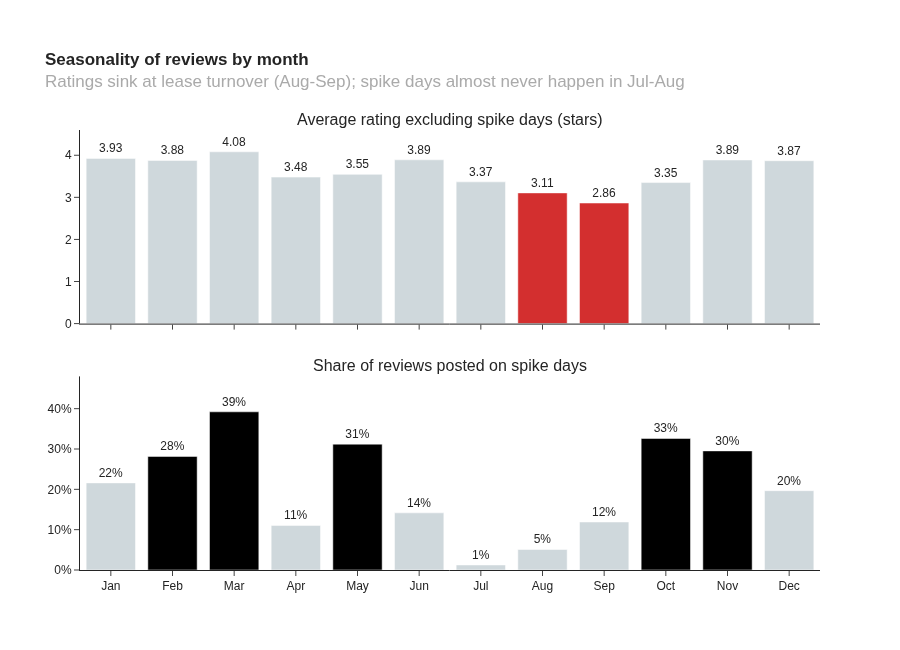

In [35]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
    subplot_titles=['Average rating excluding spike days (stars)', 'Share of reviews posted on spike days']
)
fig.add_trace(go.Bar(
    x=df_monthly['month_name'], y=df_monthly['organic_avg'],
    marker_color=np.where(df_monthly['month'].isin([8, 9]), '#D32F2F', '#CFD8DC'),
    text=df_monthly['organic_avg'].map('{:.2f}'.format), textposition='outside', showlegend=False,
), row=1, col=1)
fig.add_trace(go.Bar(
    x=df_monthly['month_name'], y=df_monthly['spike_share'],
    marker_color=np.where(df_monthly['spike_share'] >= 0.25, 'black', '#CFD8DC'),
    text=df_monthly['spike_share'].map('{:.0%}'.format), textposition='outside', showlegend=False,
), row=2, col=1)
fig.update_yaxes(range=[0, 4.6], row=1, col=1)
fig.update_yaxes(range=[0, 0.48], tickformat=',.0%', row=2, col=1)
fig.update_layout(
    title='<b>Seasonality of reviews by month</b><br>'
          '<span style="color: #aaa;">Ratings sink at lease turnover (Aug-Sep); spike days almost never happen in Jul-Aug</span>',
    width=900, height=650, margin=dict(t=130),
)
fig.show()

In [36]:
df_organic_season = df_organic.assign(
    season=np.where(df_organic['month'].isin([8, 9]), 'Aug-Sep', 'Rest of year')
)
df_season = df_organic_season.groupby(['name', 'season'])['review_rating'].mean().unstack()
df_season['gap'] = df_season['Aug-Sep'] - df_season['Rest of year']
print(f"Landlords with a lower spike-free rating in Aug-Sep: {(df_season['gap'] < 0).sum()} "
      f"of {df_season['gap'].notna().sum()}")

aug_sep = df_organic_season.query('season == "Aug-Sep"')['review_rating']
rest = df_organic_season.query('season == "Rest of year"')['review_rating']
print(f'Mann-Whitney U test, Aug-Sep vs rest of year: p = {stats.mannwhitneyu(aug_sep, rest).pvalue:.1e}')
df_organic_season.groupby('season', as_index=False).agg(
    num_reviews=('review_id', 'count'),
    avg_rating=('review_rating', 'mean'),
    one_star_share=('review_rating', lambda s: (s == 1).mean()),
).round(2)

Landlords with a lower spike-free rating in Aug-Sep: 32 of 42
Mann-Whitney U test, Aug-Sep vs rest of year: p = 1.9e-35


,season,num_reviews,avg_rating,one_star_share
0,Aug-Sep,1186,2.99,0.43
1,Rest of year,4084,3.74,0.26


- Spike-free ratings are lowest in September (2.86) and August (3.11), compared with 4.08 in March. Taken together, August-September reviews average 2.99★ with 43% 1★ reviews, compared with 3.74★ and 26% for the rest of the year (Mann-Whitney U test, p = 1.9e-35).
- The pattern is broad-based: 32 of the 42 landlords have a lower spike-free rating in August-September.
- Review drives follow the opposite calendar. Only 1% of July reviews and 5% of August reviews fall on spike days, compared with 39% in March, 33% in October, 31% in May, and 30% in November. Spike days happen during the school year, when residents are in place, and the fall months overlap with the season when students sign leases for the following year.
- Section 7 shows what the August-September complaints are about.

### 👉 7. What do unhappy tenants write about?

Three lenses on the review text, all based on simple word counts (no language model):

1. **Distinctive words.** For every word that appears in at least 20 of the 1★ and 5★ reviews, compare how often it appears in 1★ vs 5★ reviews using a smoothed log-odds ratio. Proper nouns (words that are capitalized mid-sentence most of the time, such as staff names, building names, and months) are set aside.
2. **Complaint themes.** A small keyword dictionary (regular expressions) for common complaint topics. It is deliberately simple. For example, `charg` also matches "in charge," so the shares are approximate.
3. **Themes by landlord and by month**, plus a look at review length and "likes."

In [37]:
df_1_5 = df[df['review_rating'].isin([1, 5])]
is_one_star = (df_1_5['review_rating'] == 1).to_numpy()

vectorizer = CountVectorizer(stop_words='english', min_df=20, binary=True,
                             token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b')
X = vectorizer.fit_transform(df_1_5['review_text'])

df_terms = pd.DataFrame({
    'term': vectorizer.get_feature_names_out(),
    'one_star_reviews': np.asarray(X[is_one_star].sum(axis=0)).ravel(),
    'five_star_reviews': np.asarray(X[~is_one_star].sum(axis=0)).ravel(),
})
n1, n5 = is_one_star.sum(), (~is_one_star).sum()
# smoothed log-odds ratio: > 0 means more typical of 1-star reviews
df_terms['log_odds'] = (
    np.log((df_terms['one_star_reviews'] + 1) / (n1 - df_terms['one_star_reviews'] + 1))
    - np.log((df_terms['five_star_reviews'] + 1) / (n5 - df_terms['five_star_reviews'] + 1))
)

# flag proper nouns (people, buildings, months): words capitalized mid-sentence most of the time
words = pd.Series(re.findall(r'(?<![.!?]\s)(?<!^)\b([A-Za-z][a-z]+)\b', ' '.join(df['review_text'])))
capitalized_share = words.str[0].str.isupper().groupby(words.str.lower()).mean()
df_terms['proper_noun'] = df_terms['term'].map(capitalized_share).fillna(0) > 0.7

proper = df_terms[df_terms['proper_noun']]
print(f'{len(df_terms):,} terms; {len(proper)} proper nouns set aside')
print(f"Proper nouns in 20+ five-star reviews but at most 2 one-star reviews: "
      f"{((proper['five_star_reviews'] >= 20) & (proper['one_star_reviews'] <= 2)).sum()}")

1,125 terms; 54 proper nouns set aside
Proper nouns in 20+ five-star reviews but at most 2 one-star reviews: 18


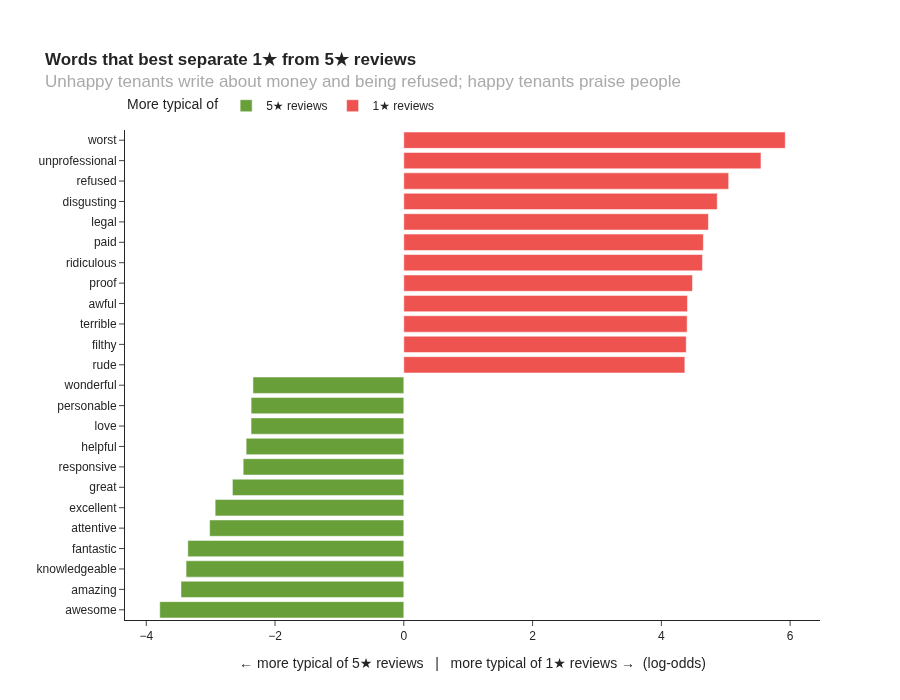

In [38]:
df_terms_plot = pd.concat([
    df_terms.query('not proper_noun').nlargest(12, 'log_odds'),
    df_terms.query('not proper_noun').nsmallest(12, 'log_odds'),
]).sort_values('log_odds')
df_terms_plot['typical_of'] = np.where(df_terms_plot['log_odds'] > 0, '1★ reviews', '5★ reviews')

fig = px.bar(
    df_terms_plot,
    x='log_odds',
    y='term',
    color='typical_of',
    color_discrete_map={'1★ reviews': '#EF5350', '5★ reviews': '#689F38'},
    orientation='h',
    hover_data=['one_star_reviews', 'five_star_reviews'],
    labels={'log_odds': '← more typical of 5★ reviews   |   more typical of 1★ reviews →  (log-odds)',
            'term': '', 'typical_of': 'More typical of'},
    title='<b>Words that best separate 1★ from 5★ reviews</b><br>'
          '<span style="color: #aaa;">Unhappy tenants write about money and being refused; happy tenants praise people</span>',
    width=900, height=700
)
fig.update_layout(legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'), margin=dict(t=130))
fig.show()

In [39]:
complaint_themes = {
    'Deposit & move-out charges': r'deposit|charg|\bfees?\b|damages|painting|carpet clean',
    'Maintenance & repairs': r'maintenance|repair|\bfix|broken|work order|leak',
    'Rude / unresponsive staff': r'\brude|unprofessional|never respond|no response|ignored|not respond'
                                 r'|didn.t respond|never called|never got back|unresponsive|disrespect',
    'Heat, AC & hot water': r'\bheat|\bheater|\bac\b|a/c|air condition|hot water|cold water|furnace',
    'Dirty at move-in': r'dirty|filthy|disgusting|not clean|wasn.t clean|unclean|trash',
    'Pests & mold': r'\bbugs?\b|roach|\bmice\b|\bmouse|rodent|\brats?\b|bed ?bugs?|\bmold|mould|\bants\b|\bpests?\b',
    'Safety & theft': r'stolen|break.?in|broke into|unsafe|\bsafety\b|theft|\bsteal',
    'Noise': r'\bnois|\bloud\b|thin walls',
}
review_text_lower = df['review_text'].str.lower()
for theme, pattern in complaint_themes.items():
    df[theme] = review_text_lower.str.contains(pattern, regex=True)

theme_cols = list(complaint_themes)
df['sentiment_group'] = np.select(
    [df['review_rating'] <= 2, df['review_rating'] >= 4], ['Negative (1-2★)', 'Positive (4-5★)'], default='Neutral (3★)'
)
df_negative = df.query('review_rating <= 2')

df_theme_share = df.groupby('sentiment_group')[theme_cols].mean().T[['Negative (1-2★)', 'Positive (4-5★)']]
df_theme_share.round(3)

sentiment_group,Negative (1-2★),Positive (4-5★)
Deposit & move-out charges,0.331,0.018
Maintenance & repairs,0.364,0.265
Rude / unresponsive staff,0.170,0.003
"Heat, AC & hot water",0.129,0.023
Dirty at move-in,0.126,0.004
Pests & mold,0.086,0.008
Safety & theft,0.080,0.005
Noise,0.054,0.012


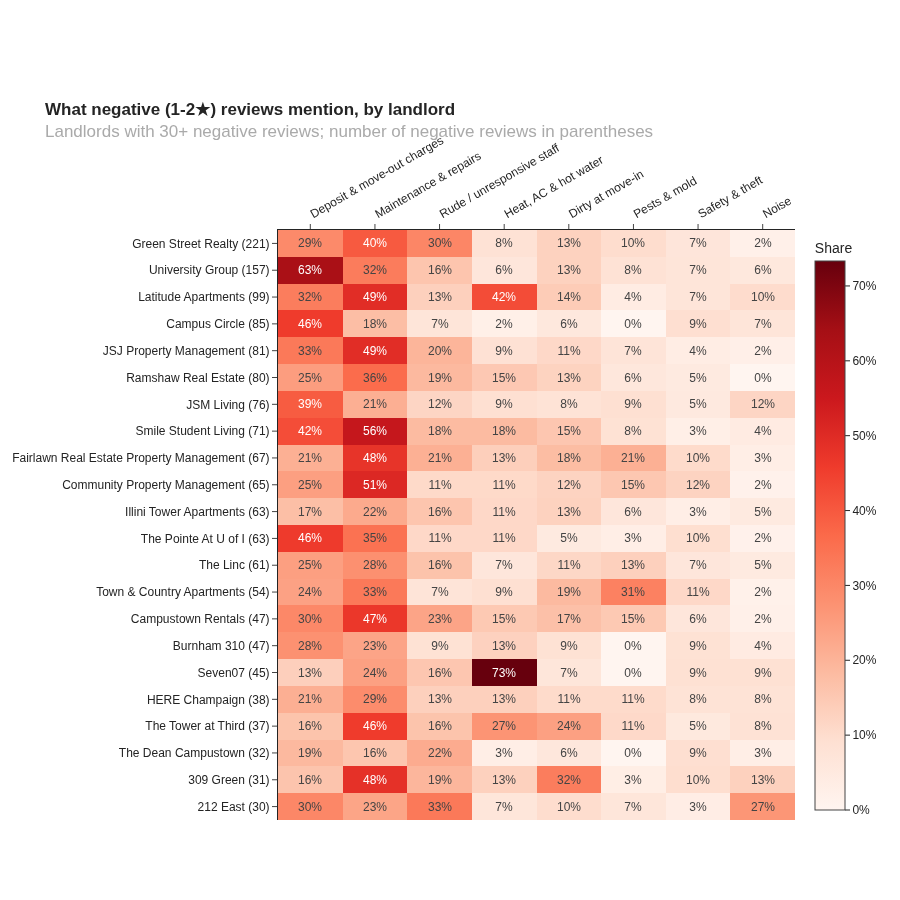

In [40]:
negative_counts = df_negative['name'].value_counts()
heatmap_landlords = negative_counts[negative_counts >= 30].index

df_heat = df_negative[df_negative['name'].isin(heatmap_landlords)].groupby('name')[theme_cols].mean()
df_heat = df_heat.loc[negative_counts[heatmap_landlords].index]  # most negative reviews first
df_heat.index = [f'{name} ({negative_counts[name]})' for name in df_heat.index]

fig = px.imshow(
    df_heat,
    text_auto='.0%',
    color_continuous_scale='Reds',
    aspect='auto',
    labels={'x': '', 'y': '', 'color': 'Share'},
    title='<b>What negative (1-2★) reviews mention, by landlord</b><br>'
          '<span style="color: #aaa;">Landlords with 30+ negative reviews; number of negative reviews in parentheses</span>',
    width=900, height=900
)
fig.update_xaxes(side='top', tickangle=-30)
fig.update_coloraxes(colorbar_tickformat=',.0%')
fig.update_layout(margin=dict(t=230))
fig.show()

In [41]:
df_negative.groupby('month', as_index=False).agg(
    negative_reviews=('review_id', 'count'),
    deposit_or_charges=('Deposit & move-out charges', 'mean'),
    dirty_at_move_in=('Dirty at move-in', 'mean'),
).assign(month=lambda d: d['month'].map(lambda m: month_labels[m - 1])).round(2).T

,0,1,2,3,4,5,6,7,8,9,10,11
month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
negative_reviews,88,122,99,137,125,109,154,283,311,171,132,96
deposit_or_charges,0.17,0.21,0.22,0.34,0.25,0.28,0.34,0.31,0.52,0.37,0.33,0.25
dirty_at_move_in,0.11,0.09,0.13,0.07,0.13,0.07,0.12,0.17,0.15,0.13,0.08,0.16


In [42]:
df.groupby('review_rating', as_index=False).agg(
    median_length=('review_length', 'median'),
    avg_likes=('review_likes', 'mean'),
    share_with_likes=('review_likes', lambda s: (s > 0).mean()),
).round(2)

,review_rating,median_length,avg_likes,share_with_likes
0,1,408.5,8.18,0.95
1,2,427.0,4.21,0.84
2,3,306.5,2.42,0.61
3,4,167.0,0.81,0.30
4,5,142.0,1.07,0.33


- **1★ reviews are about money and being stonewalled:** *worst, unprofessional, refused, disgusting, legal, paid, ridiculous, proof, awful, terrible, filthy, rude*.
- **5★ reviews are about people:** *awesome, amazing, knowledgeable, fantastic, attentive, excellent, responsive, helpful*. Of the 54 proper nouns set aside, 18 appear in 20+ five-star reviews but in at most two 1★ reviews. On inspection, these are mostly the names of leasing staff, maintenance workers, and resident assistants. Reviews that name a specific staff member are consistent with in-person review requests, the same mechanism suggested by spike days.
- **Deposits and move-out charges** appear in 33.1% of negative (1-2★) reviews but only 1.8% of positive (4-5★) reviews. Rude or unresponsive staff (17.0% vs 0.3%) and dirty units at move-in (12.6% vs 0.4%) are almost exclusively negative themes. Maintenance is the most common topic in negative reviews (36.4%), but it is also common in positive ones (26.5%): fast maintenance earns praise, and slow maintenance earns 1★.
- **Each landlord has a signature complaint.** 63% of University Group's negative reviews mention deposits or move-out charges. 73% of Seven07's mention heat, AC, or hot water (Latitude Apartments: 42%). Other standouts are pests & mold at Town & Country Apartments (31%), dirty units at move-in at 309 Green (32%), noise at 212 East (27%), and rude or unresponsive staff at 212 East (33%) and Green Street Realty (30%).
- **Deposit complaints peak right after move-out:** 52% of September's negative reviews mention deposits or charges, compared with 17-37% in every other month. This lines up with the August turnover, since Illinois landlords have roughly 30-45 days after move-out to itemize deductions and return deposits.
- **Complaints get read.** Negative reviews are longer (median 408.5 characters for 1★ vs 142 for 5★) and collect far more likes from other Google users (8.18 vs 1.07 on average). 95% of 1★ reviews have at least one like, compared with 33% of 5★ reviews.

### 👉 8. Owner responses: who replies, to whom, and does it help?

The cross-campus post looked at response times overall. Here the focus is on differences between landlords: response rates over time by landlord type, which reviews each landlord chooses to answer, and whether responding is associated with ratings.

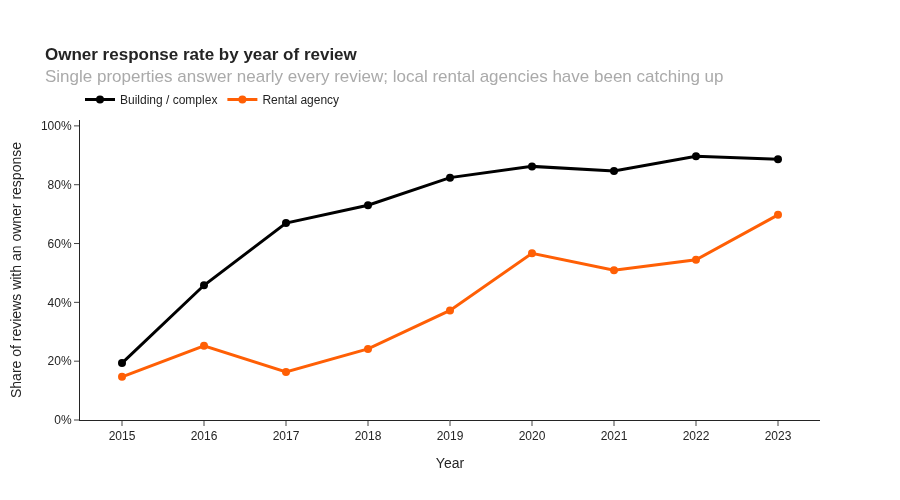

In [43]:
df_response_trend = df.query('year >= 2015').groupby(['year', 'landlord_type'], as_index=False) \
    .agg({'responded': 'mean'})

fig = px.line(
    df_response_trend,
    x='year',
    y='responded',
    color='landlord_type',
    color_discrete_map={'Building / complex': 'black', 'Rental agency': '#FF5F05'},
    markers=True,
    labels={'year': 'Year', 'responded': 'Share of reviews with an owner response', 'landlord_type': ''},
    title='<b>Owner response rate by year of review</b><br>'
          '<span style="color: #aaa;">Single properties answer nearly every review; local rental agencies have been catching up</span>',
    width=900, height=500
)
fig.update_traces(line_width=3, marker_size=8)
fig.update_layout(yaxis_tickformat=',.0%', yaxis_range=[0, 1.02],
                  legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'), margin=dict(t=120))
fig.update_xaxes(dtick=1)
fig.show()

In [44]:
df_response_trend.pivot(index='landlord_type', columns='year', values='responded').round(2)

year,2015,2016,2017,2018,2019,2020,2021,2022,2023
landlord_type,,,,,,,,,
Building / complex,0.19,0.46,0.67,0.73,0.82,0.86,0.85,0.90,0.89
Rental agency,0.15,0.25,0.16,0.24,0.37,0.57,0.51,0.54,0.70


In [45]:
df_resp = df.query('sentiment_group != "Neutral (3★)"') \
    .groupby(['name', 'sentiment_group'], as_index=False) \
    .agg(reviews=('review_id', 'count'), reply_rate=('responded', 'mean')) \
    .pivot(index='name', columns='sentiment_group', values=['reviews', 'reply_rate'])
df_resp.columns = ['negative_reviews', 'positive_reviews', 'reply_rate_negative', 'reply_rate_positive']
df_resp = df_resp.reset_index().merge(df_landlords[['name', 'num_reviews', 'verified']], on='name')
df_resp['gap'] = df_resp['reply_rate_negative'] - df_resp['reply_rate_positive']

print('Unverified Google listings (owner cannot reply):')
print(df_resp.query('not verified')[['name', 'reply_rate_negative', 'reply_rate_positive']].to_string(index=False))

# keep landlords with 10+ negative and 10+ positive reviews so the rates are not too noisy
df_resp = df_resp.query('negative_reviews >= 10 and positive_reviews >= 10 and verified').copy()
df_resp['pattern'] = np.where(df_resp['gap'] > 0, 'Replies more to negative reviews', 'Replies more to positive reviews')
print()
print(df_resp['pattern'].value_counts().to_string())
df_resp.query('num_reviews >= 150 and abs(gap) >= 0.25') \
    .sort_values('gap')[['name', 'num_reviews', 'reply_rate_positive', 'reply_rate_negative', 'gap']].round(2)

Unverified Google listings (owner cannot reply):
                         name  reply_rate_negative  reply_rate_positive
      Next Chapter Properties                  0.0                  0.0
Royse + Brinkmeyer Apartments                  0.0                  0.0

pattern
Replies more to positive reviews    16
Replies more to negative reviews    16


,name,num_reviews,reply_rate_positive,reply_rate_negative,gap
18,Illini Tower Apartments,232,0.88,0.48,-0.41
26,Ramshaw Real Estate,162,0.68,0.36,-0.32
0,212 East,203,0.99,0.73,-0.25
39,University Group,529,0.14,0.49,0.35
35,The Linc,187,0.59,0.95,0.36
7,Campustown Rentals,185,0.49,0.89,0.40
11,Fairlawn Real Estate Property Management,362,0.46,0.93,0.46


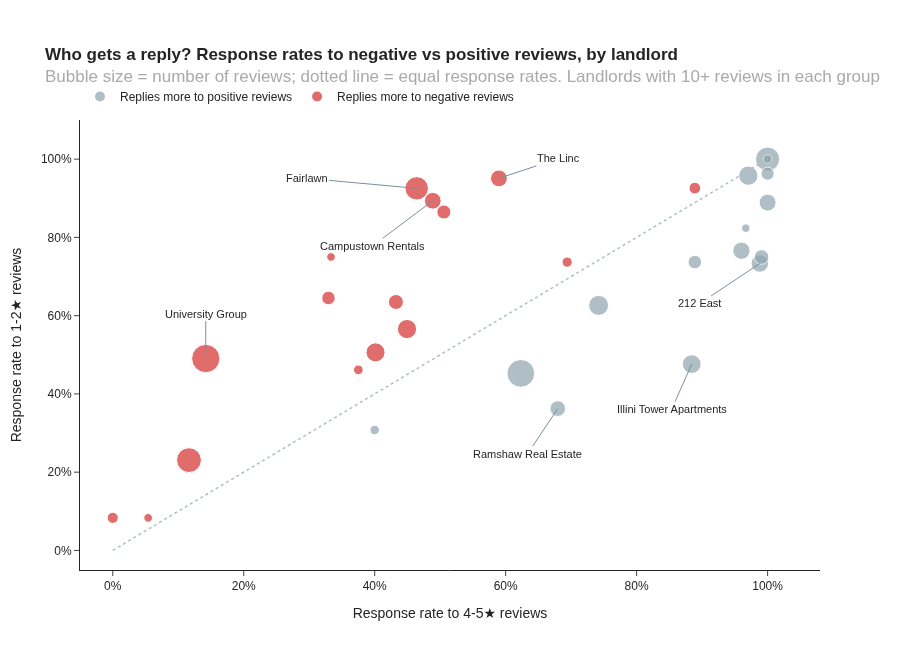

In [46]:
fig = px.scatter(
    df_resp,
    x='reply_rate_positive',
    y='reply_rate_negative',
    size='num_reviews',
    color='pattern',
    color_discrete_map={'Replies more to negative reviews': '#D32F2F', 'Replies more to positive reviews': '#90A4AE'},
    hover_name='name',
    hover_data={'num_reviews': True, 'pattern': False},
    labels={'reply_rate_positive': 'Response rate to 4-5★ reviews', 'reply_rate_negative': 'Response rate to 1-2★ reviews',
            'pattern': '', 'num_reviews': 'Reviews'},
    title='<b>Who gets a reply? Response rates to negative vs positive reviews, by landlord</b><br>'
          '<span style="color: #aaa;">Bubble size = number of reviews; dotted line = equal response rates. '
          'Landlords with 10+ reviews in each group</span>',
    width=900, height=650
)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(color='#B0BEC5', dash='dot', width=1.5),
                         showlegend=False, hoverinfo='skip'))

# label the large landlords with the biggest gaps (label offsets in pixels)
label_offsets = {
    'University Group': (0, -45), 'Fairlawn Real Estate Property Management': (-110, -10),
    'Campustown Rentals': (-60, 45), 'The Linc': (60, -20), 'Illini Tower Apartments': (-20, 45),
    'Ramshaw Real Estate': (-30, 45), '212 East': (-60, 40),
}
for _, row in df_resp[df_resp['name'].isin(label_offsets)].iterrows():
    ax, ay = label_offsets[row['name']]
    fig.add_annotation(x=row['reply_rate_positive'], y=row['reply_rate_negative'],
                       text=row['name'].replace(' Real Estate Property Management', ''),
                       ax=ax, ay=ay, showarrow=True, arrowhead=0, arrowcolor='#78909C', font_size=11)
fig.update_layout(xaxis_tickformat=',.0%', yaxis_tickformat=',.0%', xaxis_range=[-0.05, 1.08], yaxis_range=[-0.05, 1.1],
                  legend=dict(orientation='h', y=1.02, x=0, yanchor='bottom'), margin=dict(t=120))
fig.show()

In [47]:
df_responded = df[df['responded']].copy()
print(f"Responses dated before the (latest version of the) review: {(df_responded['response_days'] < 0).mean():.1%} "
      "- excluded from response-time stats")

# templated replies: identical text after removing punctuation/case
normalized = df_responded['owner_response_text'].str.lower().str.replace(r'[^a-z ]', '', regex=True).str.strip()
df_responded['templated'] = normalized.map(normalized.value_counts()) > 1
print(f"Responses whose exact wording is reused at least once: {df_responded['templated'].mean():.1%}")

df_responded.query('response_days >= 0 and sentiment_group != "Neutral (3★)"') \
    .groupby('sentiment_group', as_index=False).agg(
        responses=('review_id', 'count'),
        median_days=('response_days', 'median'),
        within_1_day=('response_days', lambda s: (s <= 1).mean()),
        within_7_days=('response_days', lambda s: (s <= 7).mean()),
    ).round(2)

Responses dated before the (latest version of the) review: 8.6% - excluded from response-time stats
Responses whose exact wording is reused at least once: 7.4%


,sentiment_group,responses,median_days,within_1_day,within_7_days
0,Negative (1-2★),986,2.68,0.31,0.72
1,Positive (4-5★),2747,1.26,0.45,0.84


In [48]:
# 1) across landlords: response rate vs spike-free rating
df_landlords = df_landlords.merge(df.groupby('name', as_index=False).agg(response_rate=('responded', 'mean')), on='name')
rho = stats.spearmanr(df_landlords['response_rate'], df_landlords['organic_shrunk_avg'])
print(f'Across landlords: Spearman rho = {rho.statistic:.2f} (p = {rho.pvalue:.2f})')

# 2) within landlords over time: does this year's response rate predict next year's spike-free rating?
df_panel = df_organic.groupby(['name', 'year'], as_index=False).agg(
    num_reviews=('review_id', 'count'),
    avg_rating=('review_rating', 'mean'),
    response_rate=('responded', 'mean'),
).sort_values(['name', 'year'])
df_panel['next_year'] = df_panel.groupby('name')['year'].shift(-1)
df_panel['next_avg_rating'] = df_panel.groupby('name')['avg_rating'].shift(-1)
df_panel['next_num_reviews'] = df_panel.groupby('name')['num_reviews'].shift(-1)
df_panel = df_panel.query('next_year == year + 1 and num_reviews >= 10 and next_num_reviews >= 10')

model = smf.ols('next_avg_rating ~ avg_rating + response_rate + C(name) + C(year)', data=df_panel).fit()
print(f"Landlord-years: {len(df_panel)} ({df_panel['name'].nunique()} landlords)")
print(f"Response-rate coefficient: {model.params['response_rate']:+.2f} stars "
      f"(95% CI {model.conf_int().loc['response_rate', 0]:+.2f} to {model.conf_int().loc['response_rate', 1]:+.2f}, "
      f"p = {model.pvalues['response_rate']:.2f})")

Across landlords: Spearman rho = -0.15 (p = 0.35)
Landlord-years: 101 (30 landlords)
Response-rate coefficient: +0.07 stars (95% CI -0.56 to +0.69, p = 0.83)


- **Responding has become the norm.** Single buildings/complexes went from replying to 19% of reviews in 2015 to about 90% in 2022-2023, while rental agencies rose from 15% to 70% in 2023. Over the whole period, buildings replied to 80% of reviews and rental agencies to 43%.
- The two unverified Google listings (Next Chapter Properties and Royse + Brinkmeyer Apartments) have no responses at all. On Google, only a verified owner can reply.
- **Landlords split evenly on whom they answer.** Among the 32 verified landlords with at least 10 negative and 10 positive reviews, 16 reply more often to negative reviews and 16 reply more often to positive ones.
    - "Damage-control" responders: Fairlawn (46% of positive vs 93% of negative reviews), Campustown Rentals (49% vs 89%), The Linc (59% vs 95%), and University Group (14% vs 49%).
    - "Thank-you" responders: Illini Tower Apartments (88% vs 48%), Ramshaw Real Estate (68% vs 36%), and 212 East (99% vs 73%).
- **Negative reviews wait longer for a reply:** a median of 2.68 days, compared with 1.26 days for positive reviews. 72% of negative and 84% of positive reviews get a reply within a week. 7.4% of responses reuse the exact wording of another response (templates). 8.6% of responses are dated before the review itself. This happens when a reviewer edits the review after the owner replied, and the data only keeps the latest version of a review.
- **Is responding associated with better ratings? Not detectably.** Across landlords, the response rate is unrelated to the spike-free rating (Spearman ρ = -0.15, p = 0.35). Within landlords over time, a landlord's response rate in one year does not predict its spike-free rating the next year: the coefficient is +0.07 stars for going from 0% to 100% responses (95% CI -0.56 to +0.69, p = 0.83), estimated from 101 landlord-years for 30 landlords with landlord and year fixed effects. This is an observational test with little statistical power. It cannot rule out a modest effect, and it says nothing about whether responses reassure *prospective* tenants, which is probably their main purpose.

## Key Findings

- **Ratings are polarized.** 63.1% of reviews are 5★ and 24.0% are 1★, so a landlord's average is essentially its 1★ share (r = -0.95). Hub on Campus (4.67), Stone Ridge Square (4.24), and 212 East (4.22) top the shrunk-average leaderboard, while Ramshaw Real Estate (3.19), Town & Country (3.25), and Green Street Realty (3.27) are at the bottom.
- **One in five reviews arrives on a "spike day."** 152 landlord-days with 5+ reviews hold 1,466 reviews (21.8%), averaging 4.76★ vs 3.57★ on other days. Illini Tower Apartments received 76 reviews on a single day (99% 5★), and three properties linked to the same national operator received 85 reviews on March 5, 2021.
- **Spike days reshape the rankings.** Without them, the overall average falls from 3.83 to 3.57. 212 East drops from #3 to #18 and University Group rises from #25 to #12. Single buildings go from out-rating rental agencies (3.91 vs 3.74) to trailing them (3.52 vs 3.60).
- **Ratings sink at lease turnover.** August-September spike-free reviews average 2.99★ with 43% 1★, compared with 3.74★ and 26% for the rest of the year. 32 of 42 landlords show the dip, and 52% of September's negative reviews mention deposits or move-out charges.
- **Complaints are about money and treatment; praise is about people.** Deposit/charge language appears in 33.1% of negative reviews vs 1.8% of positive ones. Landlords have signature complaints: deposits at University Group (63% of its negative reviews), heat or hot water at Seven07 (73%), and pests & mold at Town & Country (31%).
- **Responding is now standard, but it isn't associated with ratings.** Buildings reply to 80% of reviews and agencies to 43%. Negative reviews wait longer for a reply (median 2.68 vs 1.26 days). Response rates show no detectable link to spike-free ratings (ρ = -0.15, p = 0.35).
- **The spike-free trend shows a 2021-2022 dip** (3.30 and 3.35) that the headline average (3.84 and 3.64) largely hides.

## Case Study Potential

**Verdict: Strong.** The data is local, relatable (every student has to pick a landlord), clean, and small enough for a classroom, and it supports several findings that are genuinely surprising rather than obvious: same-day review bursts that reorder a "best landlords" list, a sharp August-September dip that ties directly to the leasing calendar, and landlord-specific complaint signatures. It also raises real questions about measurement and ethics (prompted reviews, privacy of reviewers), which make for good discussion.

**Suggested framing.** An analyst at a campus off-campus housing office (or a student-run tenant guide) must publish a fair "landlord report card" for incoming students before leasing season. Decisions: how to rank landlords with very different review counts, whether and how to adjust for review drives without accusing anyone, and what practical warnings to give students (for example, about deposits and move-in condition).

**Analytics skills exercised:** joins and groupby aggregation; datetime handling with time zones; anomaly detection with same-day counts and threshold sensitivity; Bayesian shrinkage and ranking; time-series and seasonality analysis; a nonparametric hypothesis test (Mann-Whitney); text mining with `CountVectorizer`, log-odds ratios, and regex dictionaries; a fixed-effects panel regression; visualization (stacked bars, dumbbell plots, heatmaps, small multiples); data ethics.

**Candidate student questions**

1. Build the leaderboard with prior weights of m = 10, 50, and 200. Which landlords move the most, and which version would you publish?
2. Design your own rule for flagging review bursts. How sensitive are the conclusions to the cutoff, and could the rule wrongly flag a legitimate burst (for example, angry reviews after a building outage)?
3. Is the August-September dip driven by move-out (deposits) or move-in (unit condition)? Use the theme dictionary to argue for one.
4. A student's top priority is getting the deposit back. Which landlords would you recommend or avoid, and how confident are you given the sample sizes?
5. Does replying to reviews improve ratings? Explain why the panel regression here is weak evidence, and design a better test.

**Data limitations**

- The 42 landlords were hand-picked, so this is not every landlord in Champaign-Urbana.
- Google reviews are self-selected and editable, and only the latest version and timestamp are kept.
- The spike-day rule is a heuristic. It cannot separate legitimate review requests from incentivized ones.
- The scrape ends on August 28, 2023 (local time), so 2023 is a partial year.
- The complaint themes come from crude keyword matching.
- There is no data on rents, unit counts, or occupancy, so review volume cannot be normalized by landlord size.
- Ownership links between properties (e.g., national operators) are only partly visible through listing URLs.